# NF2 Digital Companion — Survey Analysis

**Project:** NF2 patient-led care, UX case study (Google UX Certificate portfolio)
**Data:** WeChat-distributed survey of NF2 patients & caregivers, launched 2026-06-29
**Author:** Echo Zhao · **Notebook purpose:** (1) turn raw survey exports into evidence for design decisions, (2) practice the pandas/matplotlib workflow used in FIT5196.

**How to read this notebook:** every code cell carries comments explaining *why* a step exists, not just what it does. Run cells top-to-bottom (`Shift+Enter`). Figures are saved to `../figures/`, the summary table to `../reports/`.

## 0. Setup

We import only what we need. `pathlib.Path` gives us OS-independent paths, and we keep every path **relative to this notebook** (`../data/...`) — so if the parent folder is ever renamed or moved, nothing breaks as long as the internal layout stays the same.

In [1]:
# pandas = tabular data manipulation; matplotlib = plotting; Path = clean file paths.
import re                      # regular expressions — we'll need it to parse "234秒" into a number
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# All paths relative to the notebook's folder. Path("..") means "one level up".
DATA = Path("../data/NF2_Survey_Data.xlsx")
FIG  = Path("../figures")     # charts land here
REP  = Path("../reports")     # summary tables land here
FIG.mkdir(exist_ok=True)      # create the folders if they don't exist yet (idempotent)
REP.mkdir(exist_ok=True)

# One shared plot style so every figure looks consistent without repeating ourselves.
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

pd.__version__  # last expression in a cell is auto-displayed — a quick sanity check

'2.3.3'

## 1. Load the data

The Excel export has 4 sheets. We use **`AsOrder`** because:

- answers are stored as **numeric codes** (1, 2, 3…) — easier to count and recode than free text;
- multi-select questions (Q5, Q10) are already **split into one column per option** (0/1), which is exactly the "one-hot" format analysis wants.

The `MetaData` sheet documents what each code means — we'll encode that as Python dicts in section 4.

One quirk: the export's first spreadsheet row is a junk banner (`Table 1`), so the real header is on row 2 → `skiprows=1`.

In [2]:
# sheet_name picks one sheet; skiprows=1 jumps over the junk banner row.
raw = pd.read_excel(DATA, sheet_name="AsOrder", skiprows=1)

# .shape = (rows, columns). Always check this first: wrong skiprows shows up here immediately.
print("rows x cols:", raw.shape)
raw.head(3)  # eyeball the first 3 rows — do the columns look like real data?

rows x cols: (38, 25)


,序号,提交答卷时间,所用时间,来源,来源详情,来自IP,1. 您与NF2（神经纤维瘤病2型）的关系是?,2. 您或患者的年龄范围是?,3. 您目前常居的地区是?,4. 确诊NF2至今有多长时间?,...,6. 您目前如何记录和管理自己的NF2病史（如MRI、听力图、手术史、肿瘤大小波动等）?,7. 当出现新的或加重的症状时（如突发耳鸣、新的肢体麻木），您的第一反应通常是?,8. 当就诊新医生或寻求跨国/跨院医疗专家咨询时，您沟通病史的最大痛点是?,9. 您目前在患者社群（微信群等）获取或交流信息时，最大的局限性是?,10. 如果为NF2群体量身定制一款数字化陪伴工具，哪些功能对您最实用?（最多选2项）,11. （可选）我们正在征集 5-8 位患者进行深度匿名线上访谈（约30分钟，仅语音，严守隐私）以指导后续的产品原型设计。若您愿意提供帮助，请留下您的联系方式（微信/邮箱/手机号）:,10. 如果为NF2群体量身定制一款数字化陪伴工具，哪些功能对您最实用?（最多选2项）(AI报告解析: 自动识别文本MRI报告，生成清晰的肿瘤大小/毫米趋势图表),10(多维疾病时间线: 将突发症状、手术史、用药记录和复查时间串联成一条连续的直观图表),10(出诊交接仪表盘: 将厚重的病历浓缩成一页精简的报告（支持中英双语切换），方便快速向新医生出示),10(通俗前沿文献库: 将晦涩的国内外临床试验、前沿靶向药（如贝伐珠单抗）进展翻译并提炼为通俗语言)
0,1,2026/6/29 11:00:29,234秒,微信,NaN,39.144.134.114(广西-钦州),2,2,1,3,...,1,1,1,4,1.0,无,NaN,NaN,NaN,NaN
1,2,2026/6/29 11:04:54,395秒,微信,NaN,123.168.226.152(山东-潍坊),1,6,1,5,...,4,3,1,4,4.0,Xiaomage0726,NaN,NaN,NaN,NaN
2,3,2026/6/29 11:08:59,354秒,微信,NaN,27.149.104.48(福建-福州),1,4,1,4,...,4,1,1,1,3.0,18567915001,NaN,NaN,NaN,NaN


## 2. Privacy first — drop PII before any analysis

The raw export contains **IP addresses** (with city-level location) and **Q11 free-text contact details** (WeChat IDs / phone numbers of people volunteering for interviews). Rule of thumb for any dataset about real people: **strip personal identifiers in the very first transformation step**, so no later cell — or exported figure — can accidentally leak them.

Before dropping Q11 we record one *aggregate* number (how many volunteered), because that feeds the interview-recruitment plan. The actual contact strings stay only in the untouched source xlsx.

In [3]:
# Column 20 (0-indexed) is Q11's free text. Careful: don't trust documentation for
# column positions — print raw.columns and verify. (First draft of this notebook used
# index 21 from the MetaData sheet's numbering and silently kept the PII — the assert
# below now guards against exactly that.)
q11_col = raw.columns[20]
assert q11_col.startswith("11."), f"Expected Q11 at index 20, found: {q11_col[:30]}"

# .notna() alone overcounts: several people typed 无 ("none") instead of leaving it blank,
# and a few left 1–2 character junk. Free text always needs cleanup — even for a simple count.
# Rule: not a "none"-word AND at least 5 chars (the shortest plausible WeChat ID / phone / email).
q11 = raw[q11_col].astype(str).str.strip()
looks_real = raw[q11_col].notna() & ~q11.isin(["无", "没有", "否", "暂无", "没"]) & (q11.str.len() >= 5)
n_volunteers = looks_real.sum()
print(f"Interview volunteers (real contact left in Q11): {n_volunteers}")

# drop() removes columns; axis=1 is implied by columns=. We keep ONLY the count above —
# the actual contact strings live solely in the untouched source xlsx.
df = raw.drop(columns=[raw.columns[5],   # 来自IP  (IP + location)
                       raw.columns[20],  # Q11 contact details
                       raw.columns[19],  # Q10 combined text (redundant with one-hots)
                       raw.columns[4]])  # 来源详情 (all NaN)
print("after dropping PII:", df.shape)

Interview volunteers (real contact left in Q11): 30
after dropping PII: (38, 21)


### Rename columns to short codes

The export's column names are full question sentences — accurate but unusable to type. We assign short, predictable names **by position**. Positional renaming is fragile if the export format changes, so we guard it with an `assert`: if the column count is ever not 21, the notebook stops loudly here instead of silently mislabeling questions.

In [4]:
assert df.shape[1] == 21, f"Column layout changed! Expected 21 columns, got {df.shape[1]}"

df.columns = [
    "id", "submitted", "duration_raw", "channel",
    "q1_relation", "q2_age", "q3_region", "q4_years_dx",
    # Q5 multi-select: which impairments affect device use (1 = ticked, 0 = not)
    "q5_hearing", "q5_vision", "q5_motor", "q5_balance", "q5_none",
    "q6_records", "q7_first_reaction", "q8_pain_point", "q9_community",
    # Q10 multi-select: most useful features, max 2 picks (1 = picked)
    "q10_ai_parse", "q10_timeline", "q10_summary", "q10_library",
]

# Sanity check the positional rename: every one-hot column must contain only 0/1 (NaN ok).
# If a text column ever slips into these positions, this line catches it immediately.
onehots = [c for c in df.columns if c.startswith(("q5_", "q10_"))]
assert df[onehots].apply(lambda s: s.dropna().isin([0, 1]).all()).all(), "one-hot columns are not 0/1!"

df.head(3)

,id,submitted,duration_raw,channel,q1_relation,q2_age,q3_region,q4_years_dx,q5_hearing,q5_vision,...,q5_balance,q5_none,q6_records,q7_first_reaction,q8_pain_point,q9_community,q10_ai_parse,q10_timeline,q10_summary,q10_library
0,1,2026/6/29 11:00:29,234秒,微信,2,2,1,3,0,0,...,0,0,1,1,1,4,NaN,NaN,NaN,NaN
1,2,2026/6/29 11:04:54,395秒,微信,1,6,1,5,1,0,...,0,0,4,3,1,4,NaN,NaN,NaN,NaN
2,3,2026/6/29 11:08:59,354秒,微信,1,4,1,4,1,0,...,1,0,4,1,1,1,NaN,NaN,NaN,NaN


## 3. Cleaning & quality checks

Three routine steps you'll repeat in FIT5196 on every dataset:

1. **Fix dtypes** — `submitted` should be datetime, `duration_raw` ("234秒", sometimes "1分34秒") should be numeric seconds.
2. **Check duplicates** — same person submitting twice.
3. **Screen for low-effort responses** — extremely fast completions suggest random clicking. With a small sample we *flag* rather than delete; every dropped row costs us ~3% of the data.

In [5]:
# --- 1. dtypes -------------------------------------------------------------
df["submitted"] = pd.to_datetime(df["submitted"])

def to_seconds(s: str) -> int:
    """'234秒' -> 234;  '1分34秒' -> 94. Defensive: handles both export formats."""
    m = re.match(r"(?:(\d+)分)?(\d+)秒", str(s))
    mins, secs = m.groups()
    return int(mins or 0) * 60 + int(secs)

df["duration_s"] = df["duration_raw"].apply(to_seconds)

# --- 2. duplicates ----------------------------------------------------------
# id/timestamps are unique by construction, so exclude them from the comparison.
answer_cols = [c for c in df.columns if c.startswith("q")]
print("fully identical answer sets:", df.duplicated(subset=answer_cols).sum(),
      "(identical answers alone don't prove duplicates at n=38 — just worth knowing)")

# --- 3. speeders ------------------------------------------------------------
print(df["duration_s"].describe().round(0))
fast = df[df["duration_s"] < 60]
print(f"\nUnder 60 seconds: {len(fast)} respondent(s) — flagged, NOT removed. "
      "At this sample size we keep them but remember they exist when reading results.")

N = len(df)
print(f"\nWorking sample size: n = {N}")

fully identical answer sets: 0 (identical answers alone don't prove duplicates at n=38 — just worth knowing)
count     38.0
mean     253.0
std      131.0
min       75.0
25%      149.0
50%      218.0
75%      342.0
max      599.0
Name: duration_s, dtype: float64

Under 60 seconds: 0 respondent(s) — flagged, NOT removed. At this sample size we keep them but remember they exist when reading results.

Working sample size: n = 38


## 4. Who answered? (Q1–Q4)

First the boring-but-essential part: **who is in the sample**. Every later claim ("50% want a timeline") is only meaningful relative to who these 38 people are.

Two reusable pieces of machinery:

- `LABELS` — dicts mapping each numeric code to a short English label (translated from the `MetaData` sheet). Keeping labels in *one* place means a typo gets fixed once, not in six plots.
- `plot_choice()` — a helper that turns any single-choice column into a sorted horizontal bar chart of percentages. Writing the helper once beats copy-pasting plot code four times — and when you restyle it, every figure updates.

In [6]:
LABELS = {
    "q1_relation": {1: "Patient", 2: "Family / caregiver"},
    "q2_age":      {1: "<18", 2: "18–25", 3: "26–35", 4: "36–45", 5: "46–55", 6: "56+"},
    "q3_region":   {1: "Mainland China", 2: "HK / MO / TW", 3: "North America",
                    4: "Europe / UK", 5: "SE Asia", 6: "Other"},
    "q4_years_dx": {1: "<1 yr", 2: "1–3 yrs", 3: "3–5 yrs", 4: "5–10 yrs", 5: "10+ yrs"},
    "q6_records":  {1: "Paper records / folders", 2: "Manual notes / spreadsheets",
                    3: "Generic health app / hospital platform", 4: "No system — memory / rely on doctor"},
    "q7_first_reaction": {1: "Search on general platforms", 2: "Read medical literature",
                          3: "Ask the patient group", 4: "Review past MRI reports",
                          5: "Contact my doctor", 6: "Note it & observe"},
    "q8_pain_point": {1: "Records too scattered to show progression", 2: "Language barrier (medical terms)",
                      3: "Consultation too short (<10 min)", 4: "Hard to convey the timeline / causality",
                      5: "Rarely any barrier"},
    "q9_community": {1: "Info flows too fast — can't search / archive", 2: "Anxiety overload from negative cases",
                     3: "Privacy concerns (tied to WeChat identity)", 4: "Unverified / conflicting advice",
                     5: "Don't use patient groups"},
}

def plot_choice(col, title, ax=None, save=None):
    """Horizontal %-bar chart for one single-choice question.

    value_counts(normalize=True) gives proportions; .rename(LABELS[col]) swaps
    numeric codes for readable labels; sort_values puts the biggest bar on top.
    """
    shares = (df[col].value_counts(normalize=True)   # proportions, e.g. 0.42
                .rename(index=LABELS[col])           # 1 -> "Patient", ...
                .sort_values())                      # ascending -> largest ends up on top in barh
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 0.5 * len(shares) + 1))
    shares.plot.barh(ax=ax, color="#4C72B0")
    ax.set_title(f"{title}  (n={N})", loc="left")
    ax.set_ylabel("")                                       # the bar labels already say it
    ax.set_xlabel("share of respondents")
    ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")   # 0.42 -> "42%"
    for i, v in enumerate(shares):
        ax.text(v, i, f" {v:.0%}", va="center")             # print the % at each bar's tip
    if save:
        plt.gcf().savefig(FIG / save, bbox_inches="tight")
    return shares

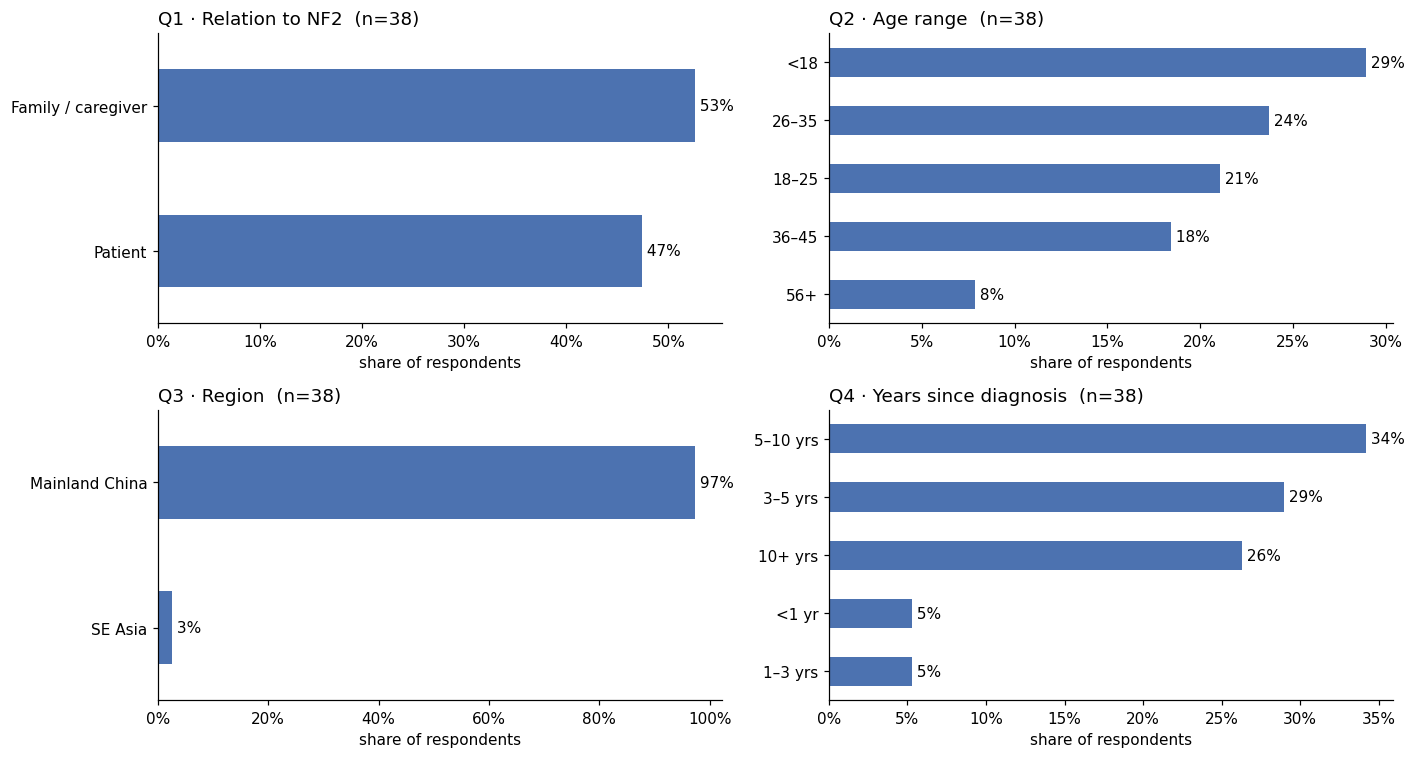

In [7]:
# 2x2 grid: one subplot per demographic question. plt.subplots(2, 2) returns
# a figure plus a 2x2 array of axes; .flat lets us iterate over them in order.
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for ax, (col, title) in zip(axes.flat, [
        ("q1_relation", "Q1 · Relation to NF2"),
        ("q2_age",      "Q2 · Age range"),
        ("q3_region",   "Q3 · Region"),
        ("q4_years_dx", "Q4 · Years since diagnosis")]):
    plot_choice(col, title, ax=ax)
fig.tight_layout()
fig.savefig(FIG / "fig1_demographics.png", bbox_inches="tight")
plt.show()

## 5. Accessibility barriers (Q5, multi-select)

Q5 asks which impairments affect phone/computer use. Because it's multi-select, the columns are already 0/1 — the **mean of a 0/1 column is directly the share who ticked it** (e.g. mean 0.4 = 40%). That one-liner is the whole reason we chose the `AsOrder` sheet.

This question is the accessibility-requirements input for the design phase: whatever we build must work for these bodies, not for a generic user.

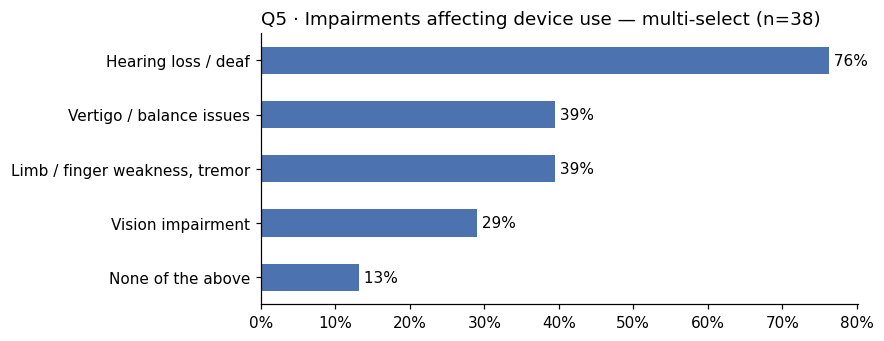

Respondents reporting at least one impairment: 87%


In [8]:
q5_map = {"q5_hearing": "Hearing loss / deaf", "q5_vision": "Vision impairment",
          "q5_motor": "Limb / finger weakness, tremor", "q5_balance": "Vertigo / balance issues",
          "q5_none": "None of the above"}

# .mean() over 0/1 columns = proportion ticked. One line, no loops.
q5 = df[list(q5_map)].mean().rename(index=q5_map).sort_values()

ax = q5.plot.barh(figsize=(7, 3.2), color="#4C72B0")
ax.set_title(f"Q5 · Impairments affecting device use — multi-select (n={N})", loc="left")
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
for i, v in enumerate(q5):
    ax.text(v, i, f" {v:.0%}", va="center")
plt.gcf().savefig(FIG / "fig2_accessibility_barriers.png", bbox_inches="tight")
plt.show()

print(f"Respondents reporting at least one impairment: {(1 - df['q5_none'].mean()):.0%}")

## 6. Current behavior & pain points (Q6–Q9)

These four questions describe the world *as it is* — how people store records today (Q6), what they actually do when a symptom appears (Q7), what hurts at the doctor's office (Q8), and what's broken in patient communities (Q9). Q7 matters doubly: in section 7 we'll use it as **revealed behavior** to sanity-check what people *say* they want.

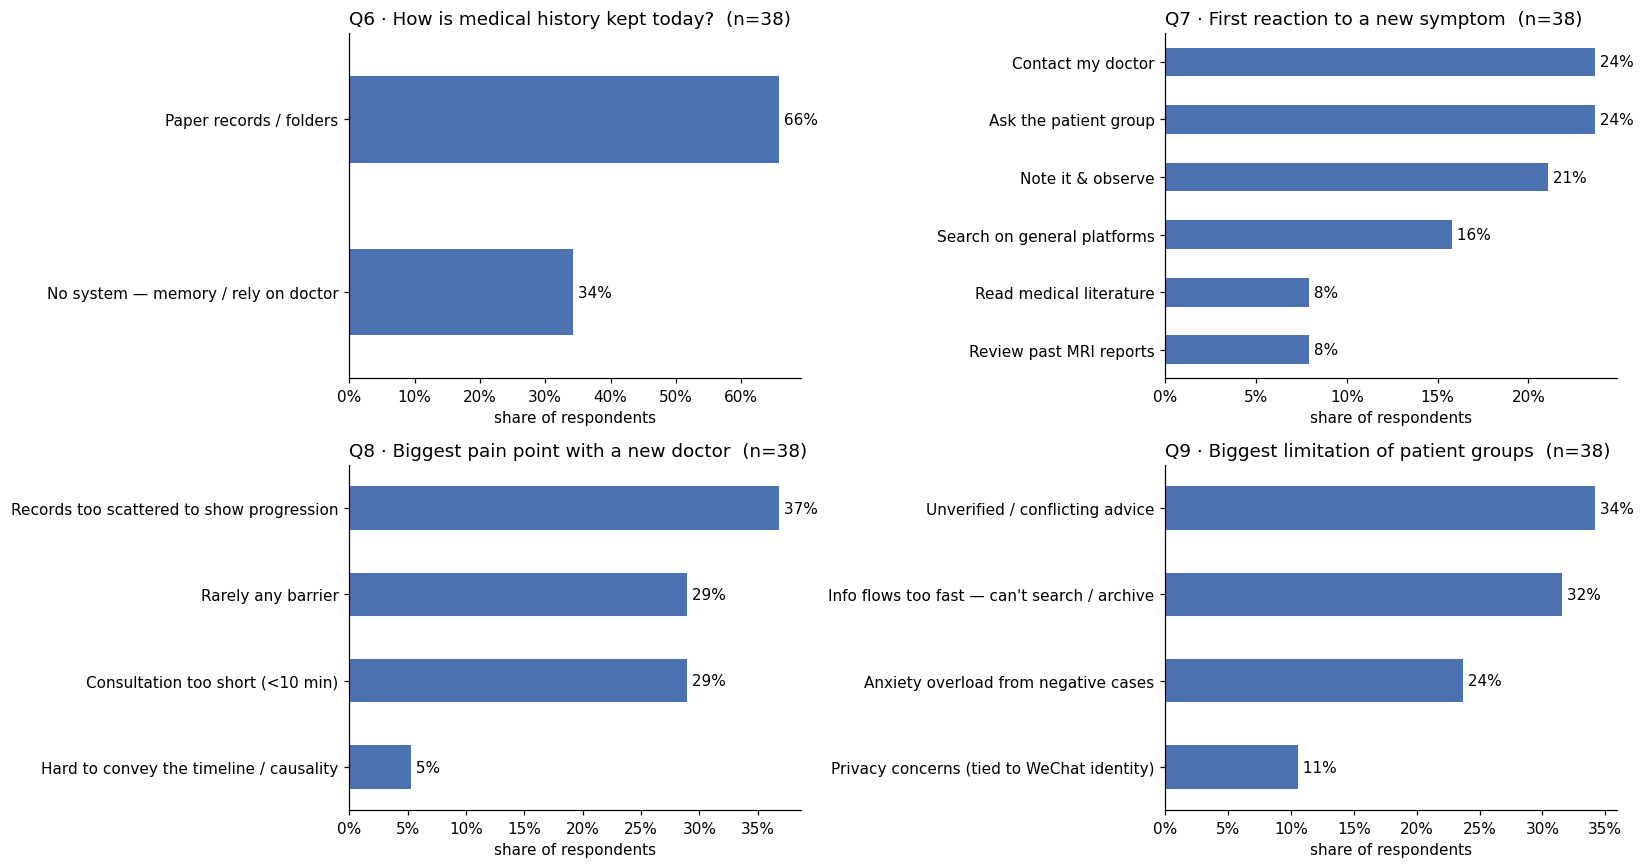

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
for ax, (col, title) in zip(axes.flat, [
        ("q6_records",        "Q6 · How is medical history kept today?"),
        ("q7_first_reaction", "Q7 · First reaction to a new symptom"),
        ("q8_pain_point",     "Q8 · Biggest pain point with a new doctor"),
        ("q9_community",      "Q9 · Biggest limitation of patient groups")]):
    plot_choice(col, title, ax=ax)
fig.tight_layout()
fig.savefig(FIG / "fig3_behavior_painpoints.png", bbox_inches="tight")
plt.show()

## 7. Feature prioritization (Q10) — stated vs. revealed preference

Q10 forced a **max-2 pick** among four candidate features. Forced ranking measures *stated preference* — and stated preference structurally favors "vitamin" features (things you'd check often) over "painkiller" features (rare but high-stakes moments). So we read Q10 **together with Q7's revealed behavior**, not on its own.

The specific hypothesis (from the n=22 interim read, logged in `HANDOVER.md`): the research library's popularity may be a *"collect it, might need it someday"* instinct rather than real usage intent — while the doctor-ready summary scores low simply because nobody expects to click "generate report" often, which says nothing about its value in the moment it's needed.

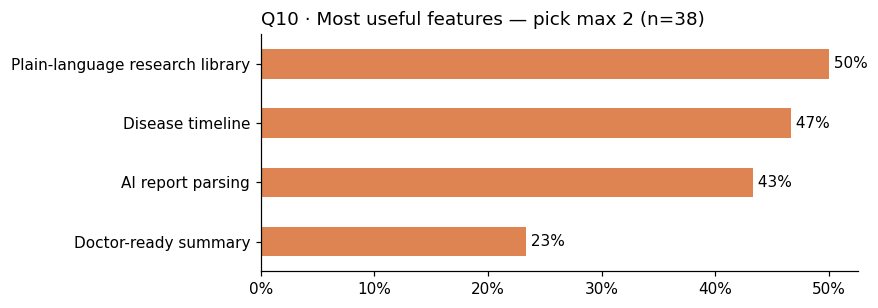

In [10]:
q10_map = {"q10_ai_parse": "AI report parsing", "q10_timeline": "Disease timeline",
           "q10_summary": "Doctor-ready summary", "q10_library": "Plain-language research library"}

q10 = df[list(q10_map)].mean().rename(index=q10_map).sort_values()

ax = q10.plot.barh(figsize=(7, 2.8), color="#DD8452")
ax.set_title(f"Q10 · Most useful features — pick max 2 (n={N})", loc="left")
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
for i, v in enumerate(q10):
    ax.text(v, i, f" {v:.0%}", va="center")
plt.gcf().savefig(FIG / "fig4_feature_priority.png", bbox_inches="tight")
plt.show()

In [11]:
# Cross-check: what do people ACTUALLY do when a symptom appears (Q7)?
# If the library were truly used, we'd expect "read medical literature" to rank high. Does it?
q7_shares = df["q7_first_reaction"].value_counts(normalize=True).rename(index=LABELS["q7_first_reaction"])

check = pd.DataFrame({
    "stated demand (Q10 pick rate)": [q10["Plain-language research library"], q10["Disease timeline"],
                                      q10["Doctor-ready summary"]],
    "related revealed behavior (Q7)": [q7_shares.get("Read medical literature", 0),
                                       q7_shares.get("Review past MRI reports", 0),
                                       q7_shares.get("Contact my doctor", 0)],
}, index=["Research library ↔ reads literature", "Timeline ↔ reviews past MRIs",
          "Doctor summary ↔ contacts doctor"])

# .map applies a function to every cell — here just for display formatting.
# (pandas also has df.style.format("{:.0%}"), which keeps numbers numeric, but it
# needs the optional jinja2 package — .map keeps the notebook dependency-free.)
check.map(lambda v: f"{v:.0%}")

,stated demand (Q10 pick rate),related revealed behavior (Q7)
Research library ↔ reads literature,50%,8%
Timeline ↔ reviews past MRIs,47%,8%
Doctor summary ↔ contacts doctor,23%,24%


In [12]:
# Bonus pandas pattern — pd.crosstab: do patients and caregivers want different things?
# normalize='index' makes each row sum to 100%, so the two groups are comparable
# even though there are more of one than the other.
ct = pd.crosstab(df["q1_relation"].map(LABELS["q1_relation"]),
                 df["q10_timeline"].map({0: "didn't pick timeline", 1: "picked timeline"}),
                 normalize="index")
ct.map(lambda v: f"{v:.0%}")

q10_timeline,didn't pick timeline,picked timeline
q1_relation,,
Family / caregiver,50%,50%
Patient,57%,43%


## 8. Key findings & limitations

The cell below computes every headline number *from the data* — no hand-typed figures that go stale when new responses arrive. Re-run the notebook on an updated export and the summary updates itself.

In [13]:
summary = pd.DataFrame({"metric": [
        "Sample size",
        "Patients (vs. caregivers)",
        "Report ≥1 impairment affecting device use",
        "No systematic record-keeping (Q6=4)",
        "First reaction = contact doctor (Q7)",
        "First reaction = review past MRIs (Q7)",
        "Pain point: records too scattered (Q8=1)",
        "Q10 pick: disease timeline",
        "Q10 pick: research library",
        "Q10 pick: AI report parsing",
        "Q10 pick: doctor-ready summary",
        "Interview volunteers (Q11)",
    ], "value": [
        f"{N}",
        f"{(df['q1_relation'] == 1).mean():.0%}",
        f"{(1 - df['q5_none'].mean()):.0%}",
        f"{(df['q6_records'] == 4).mean():.0%}",
        f"{(df['q7_first_reaction'] == 5).mean():.0%}",
        f"{(df['q7_first_reaction'] == 4).mean():.0%}",
        f"{(df['q8_pain_point'] == 1).mean():.0%}",
        f"{df['q10_timeline'].mean():.0%}",
        f"{df['q10_library'].mean():.0%}",
        f"{df['q10_ai_parse'].mean():.0%}",
        f"{df['q10_summary'].mean():.0%}",
        f"{n_volunteers}",
    ]})
summary.to_csv(REP / "survey_summary.csv", index=False)
summary

,metric,value
0,Sample size,38
1,Patients (vs. caregivers),47%
2,Report ≥1 impairment affecting device use,87%
3,No systematic record-keeping (Q6=4),34%
4,First reaction = contact doctor (Q7),24%
5,First reaction = review past MRIs (Q7),8%
6,Pain point: records too scattered (Q8=1),37%
7,Q10 pick: disease timeline,47%
8,Q10 pick: research library,50%
9,Q10 pick: AI report parsing,43%


### Limitations — keep these attached to every number above

- **Small sample.** n=38 from one recruitment channel (WeChat patient groups) — directional evidence, not statistics. No significance tests are run on purpose; at this n they would only decorate noise.
- **Sampling bias.** WeChat-group members are, by definition, people who joined patient communities; the "don't use patient groups" population is underrepresented.
- **Stated-preference bias in Q10.** Discussed in section 7 — resolve it in interviews by asking about *actual past behavior* ("when did you last read translated research content, and what did you do with it?"), not hypothetical preference.

### Next step

Recruit 5–8 interviewees from the Q11 volunteers; use the Q7-vs-Q10 tension as a core interview probe.